## Feature Engineering

5. Engineer at least 8 features from the main table: 
   - CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL 
   - ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL 
   - CREDIT_TERM = AMT_ANNUITY / AMT_CREDIT (proxy for loan term) 
   - DAYS_EMPLOYED_RATIO = DAYS_EMPLOYED / DAYS_BIRTH 
   - INCOME_PER_PERSON = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS 
   - EXT_SOURCE_MEAN = mean of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - EXT_SOURCE_STD = std of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - AGE_BUCKET = pd.cut(age, bins=[20,30,40,50,60,70,100]) 
6. Engineer at least 4 aggregation features from bureau.csv: 
   - Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE 
   - Re-run correlation analysis, engineered features should have higher correlation than original features to TARGET
   - Test for multicollinearity, drop features that have r>0.95
7. Encode categorical variables: ordinal for NAME_EDUCATION_TYPE (ordered), one-hot for others 
with <10 categories. Drop high-cardinality categoricals (>50 categories) or use frequency encoding. 
8. Save the final preprocessed DataFrame to data/preprocessed_train.csv.

### Load data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

In [2]:
clean_train_path = Path(f"{os.getcwd()}/../data/application_train_cleaned.csv")
df = pd.read_csv(clean_train_path)

In [3]:
display(df.head())
display(df.info())
display(df.describe())

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,1.0,0,0,0,0,0,0,0,0,0
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,0.0,0,0,1,0,0,0,0,0,0
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,0.0,0,0,0,0,0,0,0,0,0
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,NaN,0,0,1,1,1,1,1,1,1
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,0.0,0,0,1,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 84 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Unnamed: 0                              307511 non-null  int64  
 1   SK_ID_CURR                              307511 non-null  int64  
 2   TARGET                                  307511 non-null  int64  
 3   NAME_CONTRACT_TYPE                      307511 non-null  object 
 4   CODE_GENDER                             307511 non-null  object 
 5   FLAG_OWN_CAR                            307511 non-null  object 
 6   FLAG_OWN_REALTY                         307511 non-null  object 
 7   CNT_CHILDREN                            307511 non-null  int64  
 8   AMT_INCOME_TOTAL                        307511 non-null  float64
 9   AMT_CREDIT                              307511 non-null  float64
 10  AMT_ANNUITY                             3075

None

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307511.000000,3.075110e+05,307511.000000,307511.000000,...,265992.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,153755.000000,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.487841,5.383163e+05,0.020868,-16036.995067,...,1.899974,0.180072,0.313455,0.198253,0.135016,0.135016,0.135016,0.135016,0.135016,0.135016
std,88770.923652,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.461065,3.692890e+05,0.013831,4363.988632,...,1.869295,0.384248,0.463899,0.398684,0.341742,0.341742,0.341742,0.341742,0.341742,0.341742
min,0.000000,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76877.500000,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,153755.000000,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,230632.500000,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,...,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,307510.000000,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,...,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 5. Engineer 8 new features

In [4]:
engineered_features = []
def engineer_basic_features(dataframe, enged_features):

    # first re-add age column
    dataframe['age'] = abs(dataframe['DAYS_BIRTH'] / 365)

    # credit income ratio
    dataframe['CREDIT_INCOME_RATIO'] = dataframe['AMT_CREDIT'] / dataframe['AMT_INCOME_TOTAL']

    # annuity income ratio
    dataframe['ANNUITY_INCOME_RATIO'] = dataframe['AMT_ANNUITY'] / dataframe['AMT_INCOME_TOTAL']

    # credit term
    dataframe['CREDIT_TERM'] = dataframe['AMT_ANNUITY'] / dataframe['AMT_CREDIT']

    # days employed ratio, but first, impute sentinel to avoid NaN values being produced from division
    dataframe['DAYS_EMPLOYED'] = dataframe['DAYS_EMPLOYED'].replace(np.nan, dataframe['DAYS_EMPLOYED'].median())
    dataframe['DAYS_EMPLOYED_RATIO'] = dataframe['DAYS_EMPLOYED'] / dataframe['DAYS_BIRTH']

    # income per person
    dataframe['INCOME_PER_PERSON'] = dataframe['AMT_INCOME_TOTAL'] / dataframe['CNT_FAM_MEMBERS']

    # ext source mean
    dataframe['EXT_SOURCE_MEAN'] = dataframe[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

    # ext source standard deviation
    dataframe['EXT_SOURCE_STD'] = dataframe[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

    # age bucket/bins
    dataframe['AGE_BUCKET'] = pd.cut(dataframe['age'], bins=[20,30,40,50,60,70,100])

    enged_features += ['age', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'AGE_BUCKET']
    return dataframe

df = engineer_basic_features(df, engineered_features)

### 6. Engineer aggregation features (Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE)

In [5]:
# read in bureau dataset
bureau_path = Path(f"{os.getcwd()}/../data/bureau.csv")
bureau_df = pd.read_csv(bureau_path)

Since we want the number of active credit loans for each customer, it does not suffice to simply count the number of entries for CREDIT_ACTIVE, since this is a categorical column indicating whether that credit loan is open/closed. We'll convert this to binary column then sum up the Trues/the 1s

Now, we'll join back to the original dataframe to enrich the dataset with the aggregated features at the customer level. We use a left join since we want to retain all customers, then we'll deal with the nulls accordingly later

Now, the join introduces some new nulls to the dataset after having engineered features. Let's deal with these as follows
- For count features, NaN means that there is no count, or that the count is 0, e.g. BUREAU_COUNT = 0 means that there were 0 bureau records
- For max features, a max of NaN aligns with a max of 0, e.g. nonexistnet max of amount of credit overdue essentially means 0
- For mean features, we'll use the median, since it won't be easily affected by extreme values

In [6]:
def engineer_aggregate_features(dataframe, enged_features):
    bureau_df["CREDIT_IS_ACTIVE"] = (bureau_df["CREDIT_ACTIVE"] == "Active").astype(int)
    agg_features = bureau_df.groupby(by=['SK_ID_CURR']).agg(
        bureau_records=('SK_ID_BUREAU', 'count'),
        num_active_credits=('CREDIT_IS_ACTIVE', 'sum'),
        mean_days_credit=('DAYS_CREDIT', 'mean'),
        max_credit_sum_overdue=('AMT_CREDIT_SUM_OVERDUE', 'max')).reset_index()
    
    # join back to original df
    dataframe = dataframe.merge(agg_features, how='left', on='SK_ID_CURR')

    # fill missing data according to the logic defined above
    dataframe["bureau_records"] = dataframe["bureau_records"].fillna(0)
    dataframe["num_active_credits"] = dataframe["num_active_credits"].fillna(0)
    dataframe["max_credit_sum_overdue"] = dataframe["max_credit_sum_overdue"].fillna(0)
    dataframe["mean_days_credit"] = dataframe["mean_days_credit"].fillna(dataframe["mean_days_credit"].median())
    enged_features += ['bureau_records', 'num_active_credits', 'mean_days_credit', 'max_credit_sum_overdue']
    return dataframe

df = engineer_aggregate_features(df, engineered_features)

### 7. Encode categorical variables

First we'll drop categorical features that have high cardinality (>50\%) -- this is just noise

Next, we'll encode the `NAME_EDUCATION_TYPE` using ordinal encoding - this is the only categorical column with a hierarichal structure (this makes sense since you must progress from level to level in the education system)

Next, we'll do one-hot encoding on the columns that remain

In [7]:
def encode_categorical_features(dataframe, enged_features):
    # first find all high cardinality categorical variables and drop them from the dataset
    categorical = dataframe.select_dtypes(include=['object', 'category'])
    categorical_cols = categorical.columns
    column_counts = categorical.nunique()
    high_cardinality_columns = column_counts[column_counts > 50].index.to_list()
    enged_features += ['NAME_EDUCATION_TYPE']
    dataframe = dataframe.drop(columns=high_cardinality_columns)

    # define mapping for education
    education_mapping = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5 }
    dataframe['NAME_EDUCATION_TYPE'] = dataframe['NAME_EDUCATION_TYPE'].map(education_mapping)
    columns_to_encode = [col for col in categorical_cols if col not in high_cardinality_columns and col != 'NAME_EDUCATION_TYPE']
    numeric_columns = dataframe.drop(columns=['Unnamed: 0', 'SK_ID_CURR']).select_dtypes(include=['number']).columns.to_list()
    one_hot_encoded = pd.get_dummies(dataframe[columns_to_encode], dtype=int)
    dataframe = pd.concat([dataframe, one_hot_encoded], axis=1).drop(columns=columns_to_encode)
    return (dataframe, columns_to_encode, numeric_columns)

df, CATEGORICAL_COLUMNS, NUMERIC_COLUMNS = encode_categorical_features(df, engineered_features)

In [8]:
import pickle

with open("../src/feature_lists.pkl", "wb") as f:
    pickle.dump(
        {
            "numeric_features": NUMERIC_COLUMNS,
            "categorical_features": CATEGORICAL_COLUMNS
        },
        f
    )

### Re-run correlation analysis

In [9]:
fts = df.drop(columns=['TARGET'])
target_correlation = fts.corrwith(df['TARGET'], numeric_only=True).sort_values(ascending=False).head(30)
display(target_correlation)

mean_days_credit                          0.082079
DAYS_BIRTH                                0.078239
EXT_SOURCE_STD                            0.071962
DAYS_EMPLOYED                             0.063368
REGION_RATING_CLIENT_W_CITY               0.060893
REGION_RATING_CLIENT                      0.058899
NAME_INCOME_TYPE_Working                  0.057481
DAYS_LAST_PHONE_CHANGE                    0.055218
CODE_GENDER_M                             0.054713
DAYS_ID_PUBLISH                           0.051457
AGE_BUCKET_(20, 30]                       0.051445
REG_CITY_NOT_WORK_CITY                    0.050994
FLAG_EMP_PHONE                            0.045982
REG_CITY_NOT_LIVE_CITY                    0.044395
FLAG_DOCUMENT_3                           0.044346
num_active_credits                        0.043569
OCCUPATION_TYPE_Laborers                  0.043019
DAYS_REGISTRATION                         0.041975
AGE_BUCKET_(30, 40]                       0.033524
missingness_AMT_REQ_CREDIT_BURE

From the above output our newly engineered variables are among some of the highest correlated features with the target. A Pearson correlation of $|r|<0.1$> is not immediate cause for concern as financial datasets come with a lot of nonlinearity and interaction effects

### Testing for multicollinearity

<Axes: >

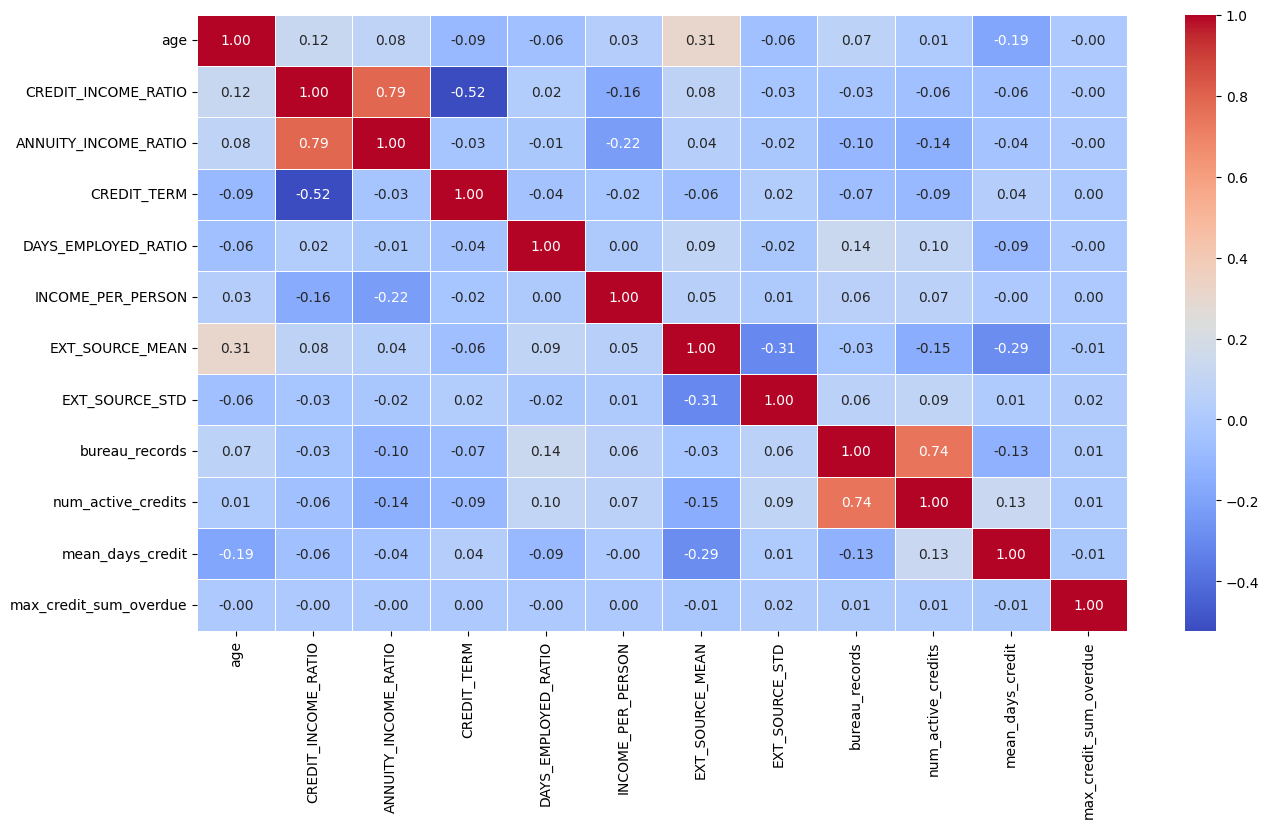

In [10]:
engineered_features.remove('AGE_BUCKET')
engineered_features.remove('NAME_EDUCATION_TYPE')
engineered_features_df = df[engineered_features]
corr_matrix = engineered_features_df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt
# plot heatmap
plt.figure(figsize=(15,8))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [11]:
display(df.isna().sum()[df.isna().sum() > 0])
has_nulls = df.isna().sum()[df.isna().sum() > 0].index

EXT_SOURCE_3                  60965
AMT_REQ_CREDIT_BUREAU_HOUR    41519
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
dtype: int64

We still have some nulls to take care of, since using models on null values usually doesn't go well. We first get the columns that still have nulls. The `AMT_REQ` features have missingness indicators, but let's still impute, the missingness indicators are a signal to the model that data was originally missing. Same with `EXT_SOURCE_3`

In [12]:
df[has_nulls] = df[has_nulls].fillna(df[has_nulls].median())

In [13]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

### Save preprocessed dataframe

In [14]:
preprocessed_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df.to_csv(preprocessed_path, index=False)

## Unsupervised Learning: K-Means Clustering

In [15]:
clustering_df = pd.read_csv(preprocessed_path)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# import kmeans
from sklearn.cluster import KMeans

# plotting
import matplotlib.pyplot as plt


### Select numerical features for clustering and normalize using StandardScaler
This puts all the features on the same scale, which is essential because we are using Euclidean distance. Not having features on the same scale would severely distort the distance

In [16]:

features_to_cluster = ['age', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD']
clustering_data = clustering_df[features_to_cluster]

scaler = StandardScaler()
# normalize the data
normalized_data = scaler.fit_transform(clustering_data)

### Run k-Means with k=2 to k=8. Plot the elbow curve (inertia vs. k) and silhouette score vs. k. Choose the optimal k

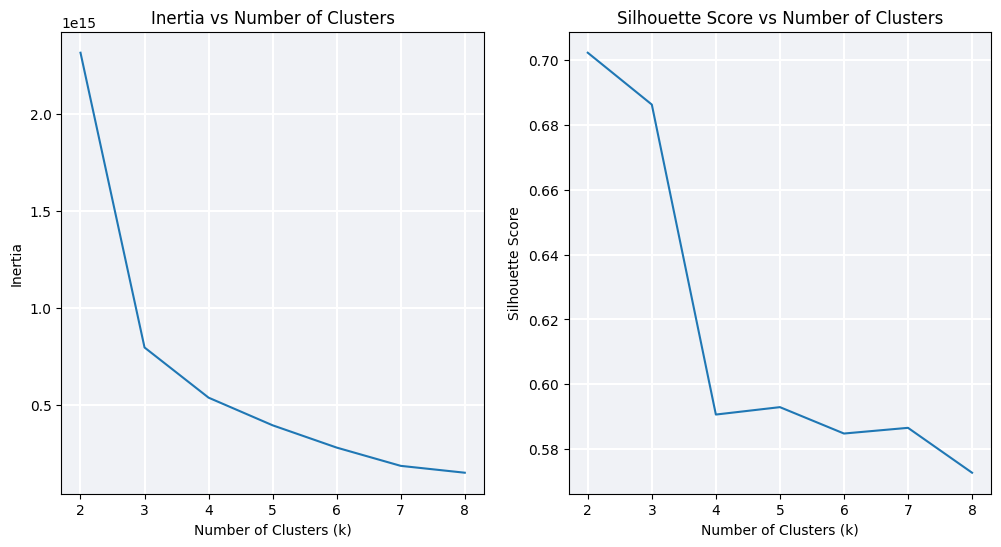

In [17]:
k_clusters = range(2,9)
inertia = []
silhouettes = []

# use a sample size of 10000 for silhouette scores to produce a similar result to a full calculation
for k in k_clusters:
    # initialize a separate model for each k
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(clustering_data)

    inertia.append(kmeans.inertia_)
    score = silhouette_score(X=clustering_data, labels=labels, sample_size=10000)
    silhouettes.append(score)

# plot inertia and silhouette score
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax1, ax2 = axes
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Inertia vs Number of Clusters')
ax1.grid(
    visible=True,       
    which='major',      
    axis='both',        
    color='white',      
    linestyle='-',      
    linewidth=1.5,      
    alpha=1.0           
)
ax1.set_facecolor('#f0f2f6')
ax1.plot(k_clusters, inertia)

ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(
    visible=True,       
    which='major',     
    axis='both',        
    color='white',      
    linestyle='-',      
    linewidth=1.5,      
    alpha=1.0           
)
ax2.set_facecolor("#f0f2f6")
ax2.plot(k_clusters, silhouettes)

Based on the above plot, it seems that $k=3$ is the optimal number of clusters. We can clearly see an elbow in the graph at said point

### Fit with optimal k and add cluster label as feature to application dataset

In [18]:
best_k_means = KMeans(n_clusters=3, random_state=42)

# assign customer segments as a feature
clustering_df['customer_segment'] = best_k_means.fit_predict(normalized_data)
display(clustering_df.head())

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,...,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]",customer_segment
0,0,100002,1,0,202500.0,406597.5,24700.5,351000.0,2,0.018801,...,0,0,1,1,0,0,0,0,0,0
1,1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,4,0.003541,...,0,0,0,0,0,1,0,0,0,0
2,2,100004,0,0,67500.0,135000.0,6750.0,135000.0,2,0.010032,...,0,0,0,0,0,0,1,0,0,1
3,3,100006,0,0,135000.0,312682.5,29686.5,297000.0,2,0.008019,...,0,0,1,0,0,0,1,0,0,1
4,4,100007,0,0,121500.0,513000.0,21865.5,513000.0,2,0.028663,...,1,0,0,0,0,0,1,0,0,1


### Profile each cluster: compute mean of key features and default rate per cluster. Give each cluster a descriptive business name

In [19]:
# multiple aggregation

cluster_aggregation = clustering_df.groupby(by=['customer_segment'])[features_to_cluster + ['TARGET']].agg('mean')
cluster_aggregation

,age,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,DAYS_EMPLOYED_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_STD,TARGET
customer_segment,,,,,,,,,
0,36.963840,2.843592,0.152543,0.059669,0.127329,92210.944733,0.401295,0.204193,0.138289
1,47.502964,2.822537,0.143432,0.056428,0.149910,108107.994549,0.574393,0.105337,0.045924
2,46.831063,7.765597,0.294792,0.039857,0.148915,64934.152107,0.532949,0.135206,0.067377


To be able to profile our clusters, we need to first understand what each of the averages shown above mean:

- age: average age
- CREDIT_INCOME_RATIO: average ratio of loan credit amount to total income of client
- ANNUITY_INCOME_RATIO: average ratio of the loan instalment amount to total income of client
- CREDIT_TERM: average duration of loan until being paid off
- DAYS_EMPLOYED_RATIO: average ratio of days employed to days since birth
- INCOME_PER_PERSON: average income per person of household of applicant
- EXT_SOURCE_MEAN: average of mean of normalized score from three external sources
- EXT_SOURCE_STD: average of standard deviation of normalized score from three external sources
- TARGET: default rate per cluster


Based on the above information, here are the profiles for each cluster:

- **Cluster 0**: These applicants appear to be financially established individuals with relatively high incomes and strong external credit histories. Their debt burden is manageable relative to income, making them the safest customer segment.
- **Cluster 1**: Although these customers are not highly leveraged, they exhibit poor external credit profiles. Their younger age and weaker credit history suggest they may have shorter or less established borrowing histories, contributing to the highest observed default rate.
- **Cluster 2**: This segment consists of borrowers carrying substantially larger loans relative to their income. Despite having reasonably good external credit scores, their high leverage increases their probability of default. They represent a medium-risk group where affordability, rather than credit history, appears to be the primary concern.

### Testing whether clustering improves best model from notebook 4

In [20]:
# load model
import joblib
model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")

with open(model_path, mode='rb') as f:
    best_model = joblib.load(f)

In [21]:
# one-hot encoding
customer_segments_one_hot = pd.get_dummies(data=clustering_df['customer_segment'])
clustering_df = pd.concat([clustering_df, customer_segments_one_hot], axis=1).drop(columns=['customer_segment'])

In [22]:
# rename columns for better readability
clustering_df = clustering_df.rename(columns={0: 'Segment_0', 1: 'Segment_1', 2: 'Segment_2'})

segment_columns = [f"Segment_{k}" for k in range(3)]

clustering_df[segment_columns] = clustering_df[segment_columns].astype(int)

In [23]:
# re-run training and evaluation
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

X, y = clustering_df.drop(columns=['TARGET']), clustering_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

y_pred_proba = best_model.fit(X_train, y_train).predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_pred_proba)

print(f"AUROC with customer segmentation is: {auroc :4f}")

AUROC with customer segmentation is: 0.753408


It seems that the customer segmentation feature has helped the model's performance, although the difference is quite marginal - the performance is similar in both cases (with/without)